<div style='text-align: center'>
    <p style='font-size:50px; margin-bottom: 0px'>Scale heights</p>
    <o style='font-size:20px;'>This notebook handles calculating scale heights for the fiducial model</p>
</div>

In [2]:
import cogsworth
import astropy.units as u
import astropy.constants as const
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import gala.dynamics as gd
import gala.potential as gp
from gala.units import galactic
from scipy.integrate import cumulative_trapezoid
from astropy.coordinates import SkyCoord
from scipy.ndimage import gaussian_filter
import seaborn as sns
import os

import sys
sys.path.append('../src')
import plotting, helpers
from importlib import reload

%config InlineBackend.figure_format = 'retina'


pd.options.display.max_columns = 999

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

In [3]:
files = ["fiducial"]
labels = ["Fiducial"]
colours = ["tab:blue"]

In [4]:
pops, data = helpers.load_postprocessed_pops(files, labels, colours)

Loading post-processed data for Fiducial from fiducial


In [5]:
pop = pops[0]

In [6]:
scale_up = 6e10 / data["Fiducial"]["mass_binaries"]
scale_up

np.float64(96.02349884125425)

In [9]:
if os.path.exists("/mnt/ceph/users/twagg/underworld/stars_sfh.h5"):
    stars = cogsworth.sfh.load("/mnt/ceph/users/twagg/underworld/stars_sfh.h5")
else:
    stars = cogsworth.sfh.SandersBinney2015(
        **{
            "potential": gp.MilkyWayPotential(version='v2'),
            "time_bins": 5,
            "verbose": True,
            "include_bar": False,
        }
    )
    stars.sample(n_bh)
    stars.save("/mnt/ceph/users/twagg/underworld/stars_sfh")

# CDF method

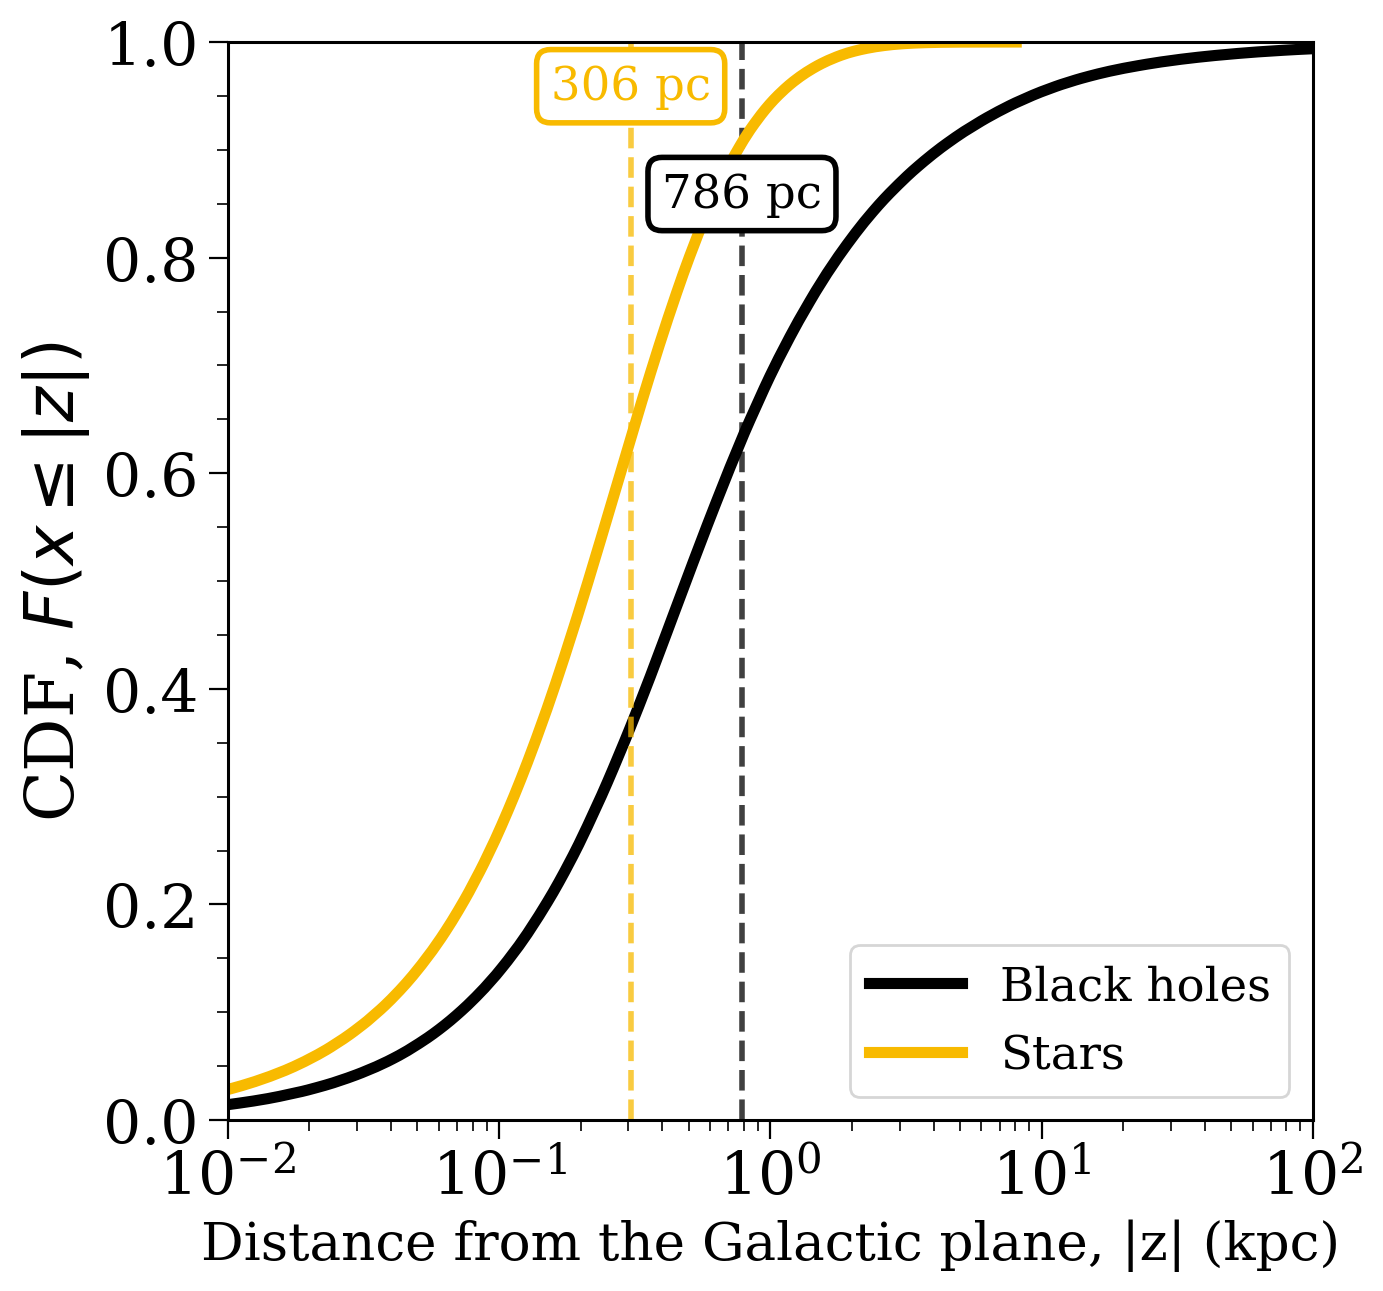

In [9]:
fig, ax = plt.subplots(figsize=(7, 7))

reload(plotting)

for z, label, colour, loc in zip(
    [data["Fiducial"]["pos"]["BH"][:, 2][~data["Fiducial"]["escaped"]["BH"]], stars.z],#, data["Fiducial"]["pos"]["NS"][:, 2][~data["Fiducial"]["escaped"]["NS"]]],
    ["Black holes", "Stars", "Neutron stars"],
    ["black", "#F8BA00", "tab:purple"],
    [0.98 - 0.1, 0.98, 0.98 - 2 * 0.08]
):

    sh, sh_err, _, _ =plotting.estimate_scale_height_cdf(
        z=z,
        plot=True,
        label=label,
        colour=colour,
        show=False,
        fig=fig,
        ax=ax,
        xlim=(1e-2, 1e2),
        ylim=(0, 1.0),
        ylabel=r"CDF, $F(x \leq |z|)$",
        scale_height_loc=loc,
        R=None,
    )

# add minor ticks every 0.1 kpc
# ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.05))

plt.savefig("../plots/scale_height_blackholes_vs_stars.pdf", format="pdf", bbox_inches='tight')
plt.show()

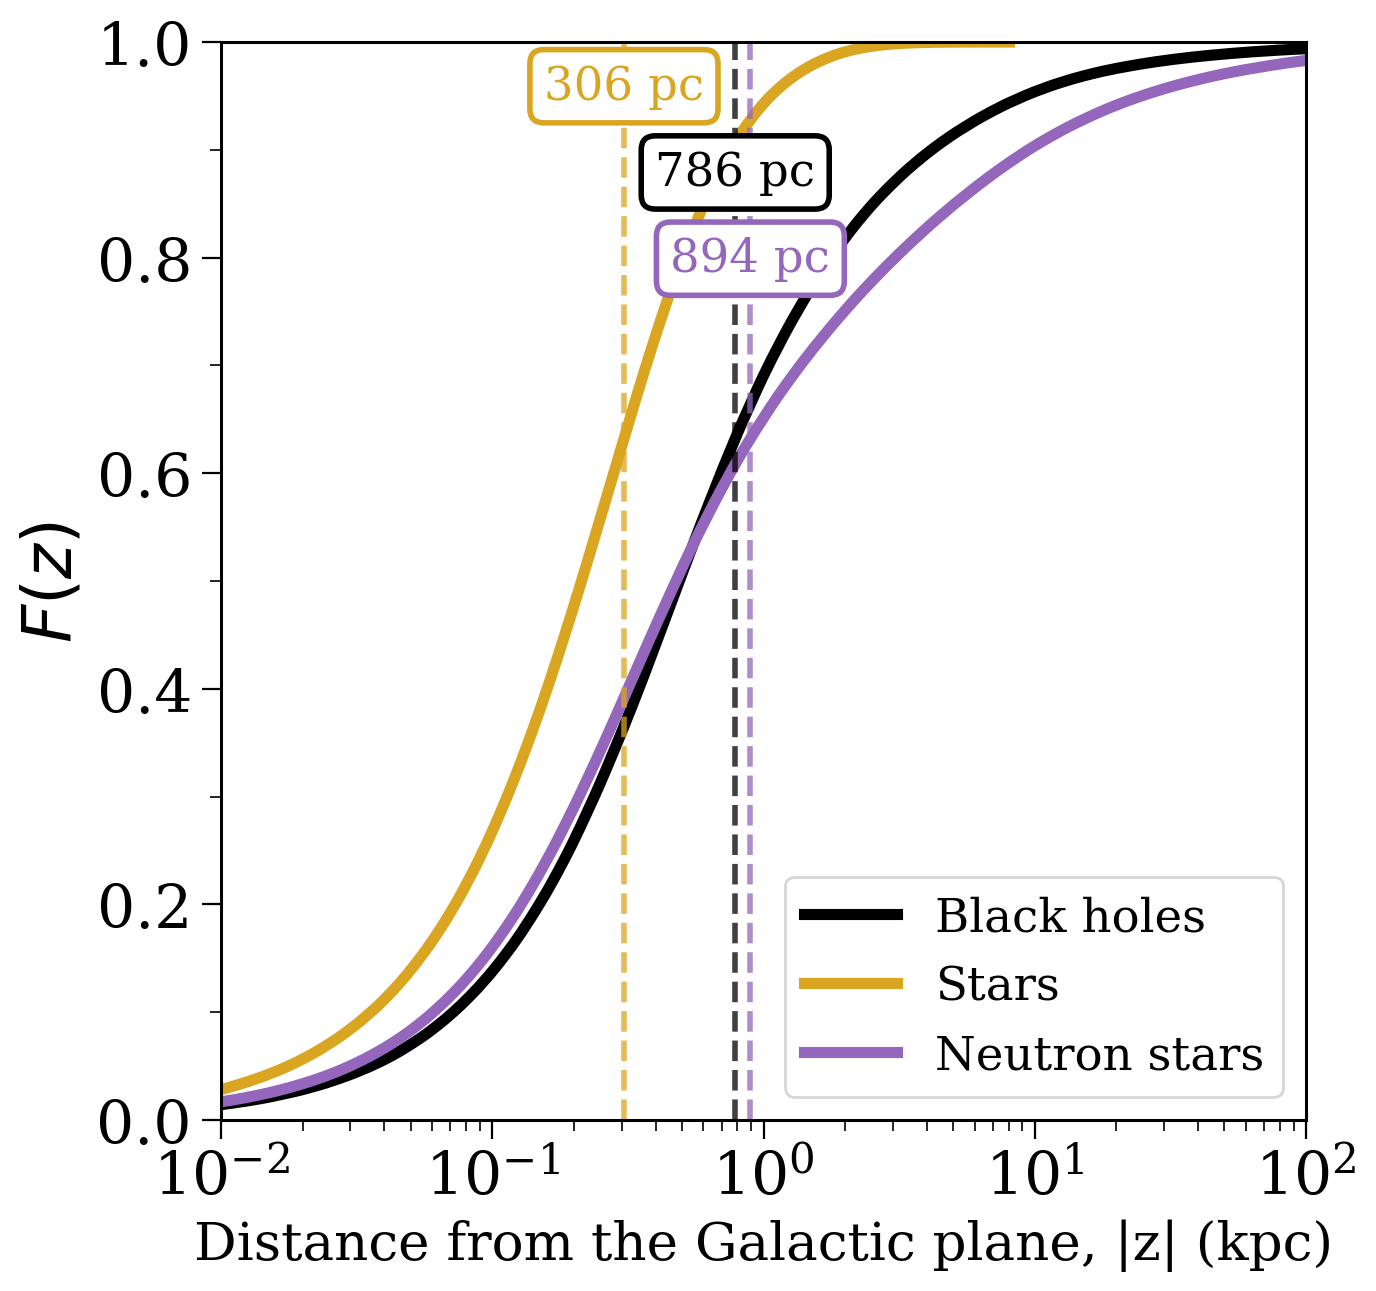

In [21]:
fig, ax = plt.subplots(figsize=(7, 7))

reload(plotting)

for z, label, colour, loc in zip(
    [data["Fiducial"]["pos"]["BH"][:, 2][~data["Fiducial"]["escaped"]["BH"]], stars.z, data["Fiducial"]["pos"]["NS"][:, 2][~data["Fiducial"]["escaped"]["NS"]]],
    ["Black holes", "Stars", "Neutron stars"],
    ["black", "goldenrod", "tab:purple"],
    [0.98 - 0.08, 0.98, 0.98 - 2 * 0.08]
):

    sh, sh_err, _, _ =plotting.estimate_scale_height_cdf(
        z=z,
        plot=True,
        label=label,
        colour=colour,
        show=False,
        fig=fig,
        ax=ax,
        xlim=(1e-2, 1e2),
        ylim=(0, 1.0),
        # yscale="log",
        scale_height_loc=loc,
        R=None,
    )

# add minor ticks every 0.1 kpc
# ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))

# plt.savefig("../plots/scale_height_blackholes_vs_stars.pdf", format="pdf", bbox_inches='tight')
plt.show()

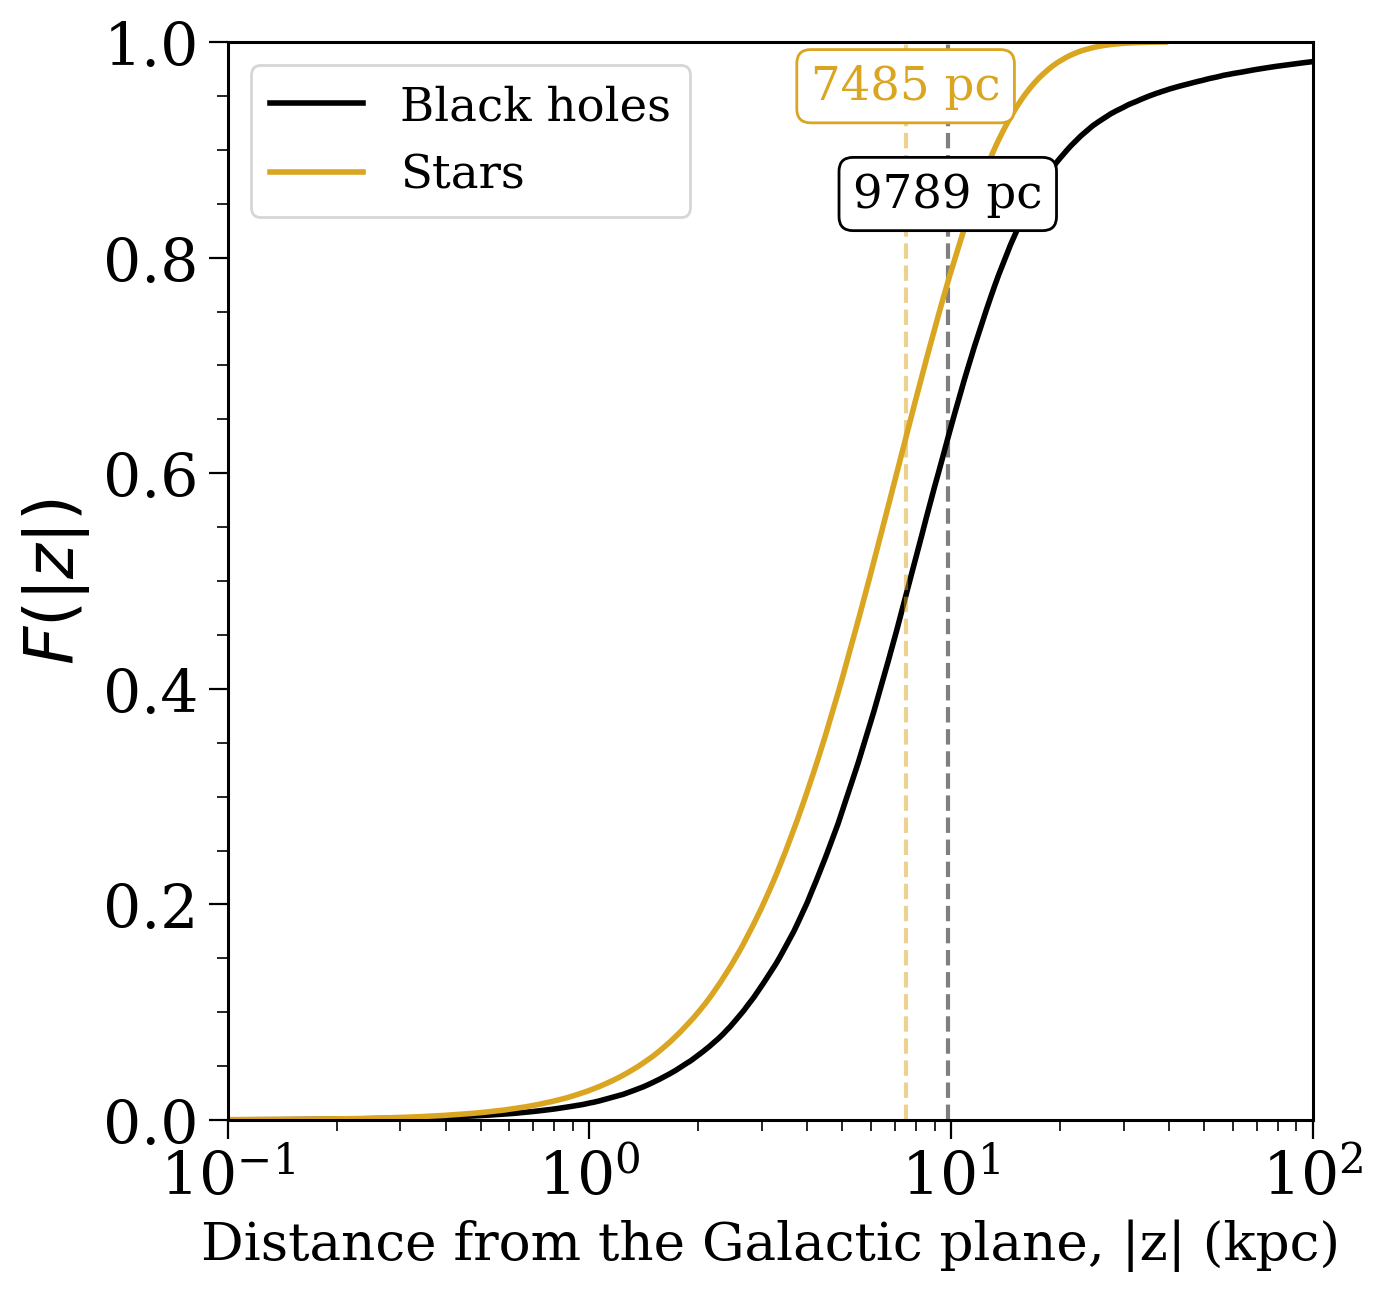

In [ ]:
fig, ax = plt.subplots(figsize=(7, 7))

reload(plotting)

rho = np.sum(data["Fiducial"]["pos"]["BH"][:, :2]**2, axis=1)**(0.5)

for z, label, colour, loc in zip(
    [rho[~data["Fiducial"]["escaped"]["BH"]], stars.rho],
    ["Black holes", "Stars", "Neutron stars"],
    ["black", "goldenrod", "tab:purple"],
    [0.98 - 0.1, 0.98, 0.98 - 2 * 0.08]
):

    sh, sh_err, _, _ =plotting.estimate_scale_height_cdf(
        z=z,
        plot=True,
        label=label,
        colour=colour,
        show=False,
        fig=fig,
        ax=ax,
        xlim=(1e-1, 1e2),
        ylim=(0, 1.0),
        ylabel=r"$F(|z|)$",
        scale_height_loc=loc,
        R=None,
    )

# add minor ticks every 0.1 kpc
# ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.05))

# plt.savefig("../plots/scale_height_blackholes_vs_stars.pdf", format="pdf", bbox_inches='tight')
plt.show()

# Without masking escaped ones

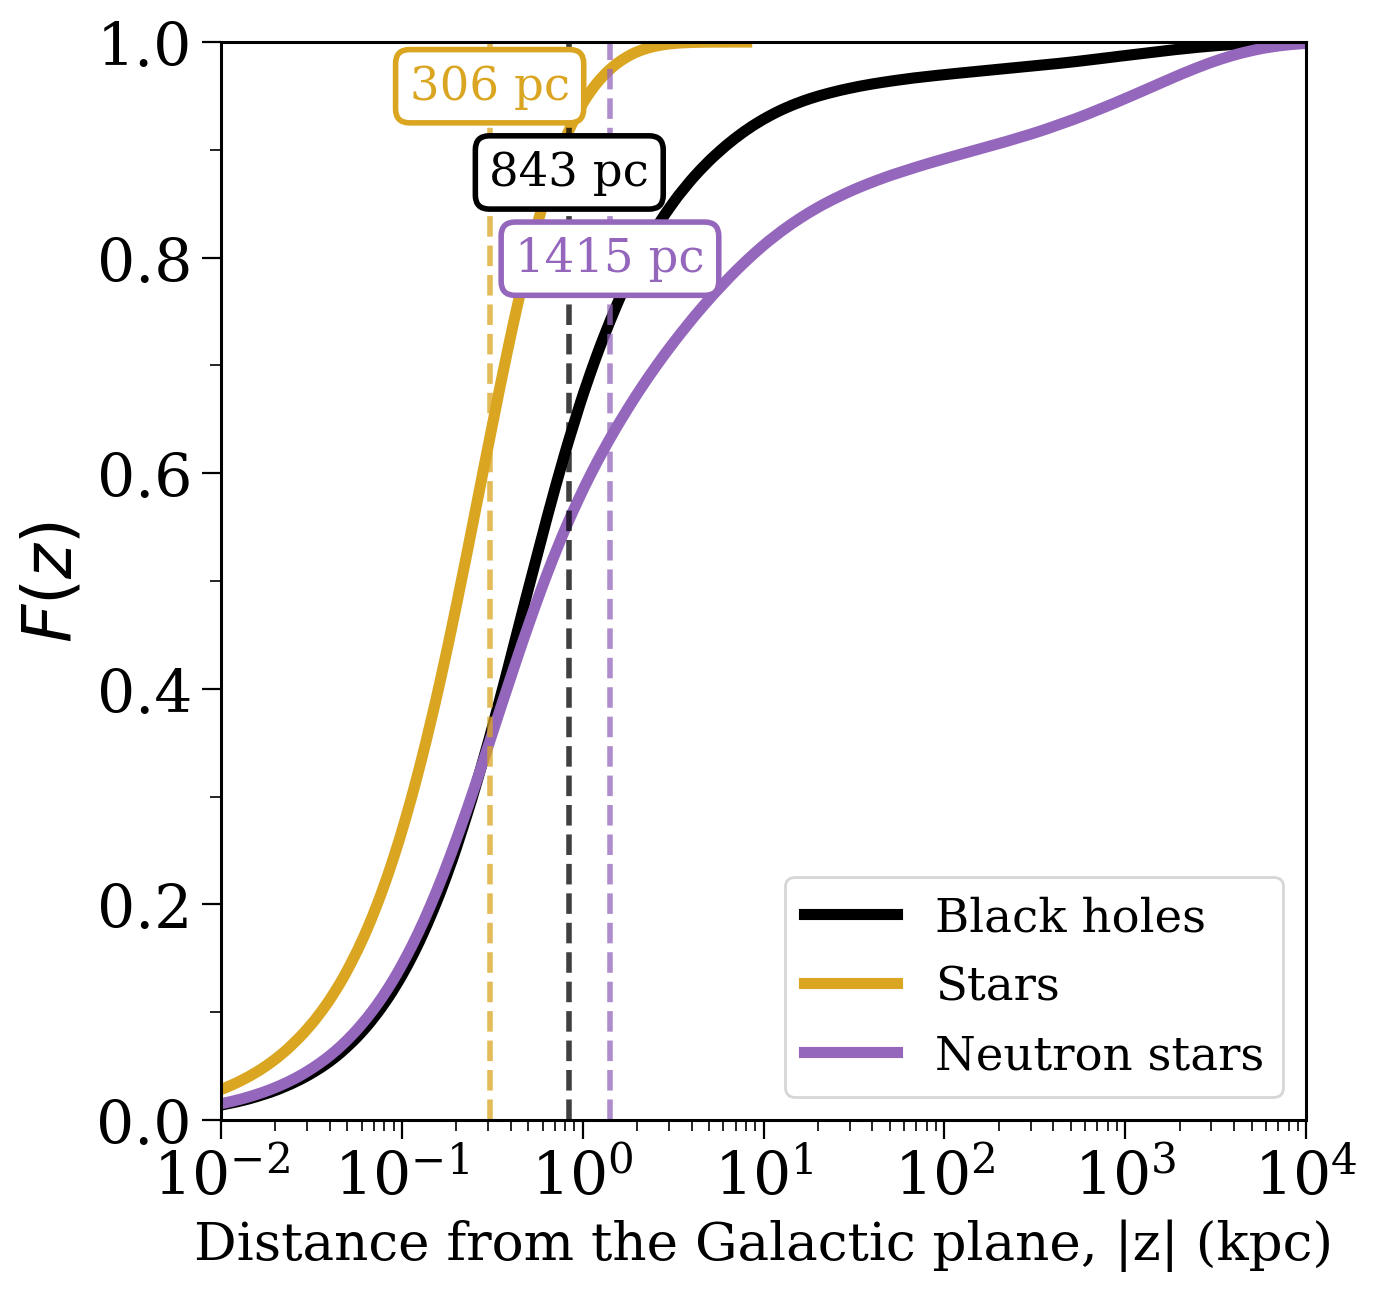

In [22]:
fig, ax = plt.subplots(figsize=(7, 7))

reload(plotting)

for z, label, colour, loc in zip(
    [data["Fiducial"]["pos"]["BH"][:, 2], stars.z, data["Fiducial"]["pos"]["NS"][:, 2]],
    ["Black holes", "Stars", "Neutron stars"],
    ["black", "goldenrod", "tab:purple"],
    [0.98 - 0.08, 0.98, 0.98 - 2 * 0.08]
):

    sh, sh_err, _, _ =plotting.estimate_scale_height_cdf(
        z=z,
        plot=True,
        label=label,
        colour=colour,
        show=False,
        fig=fig,
        ax=ax,
        xlim=(1e-2, 1e4),
        ylim=(0, 1.0),
        # yscale="log",
        scale_height_loc=loc,
        R=None,
    )

# add minor ticks every 0.1 kpc
# ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))

# plt.savefig("../plots/scale_height_blackholes_vs_stars.pdf", format="pdf", bbox_inches='tight')
plt.show()

# Solar neighbourhood

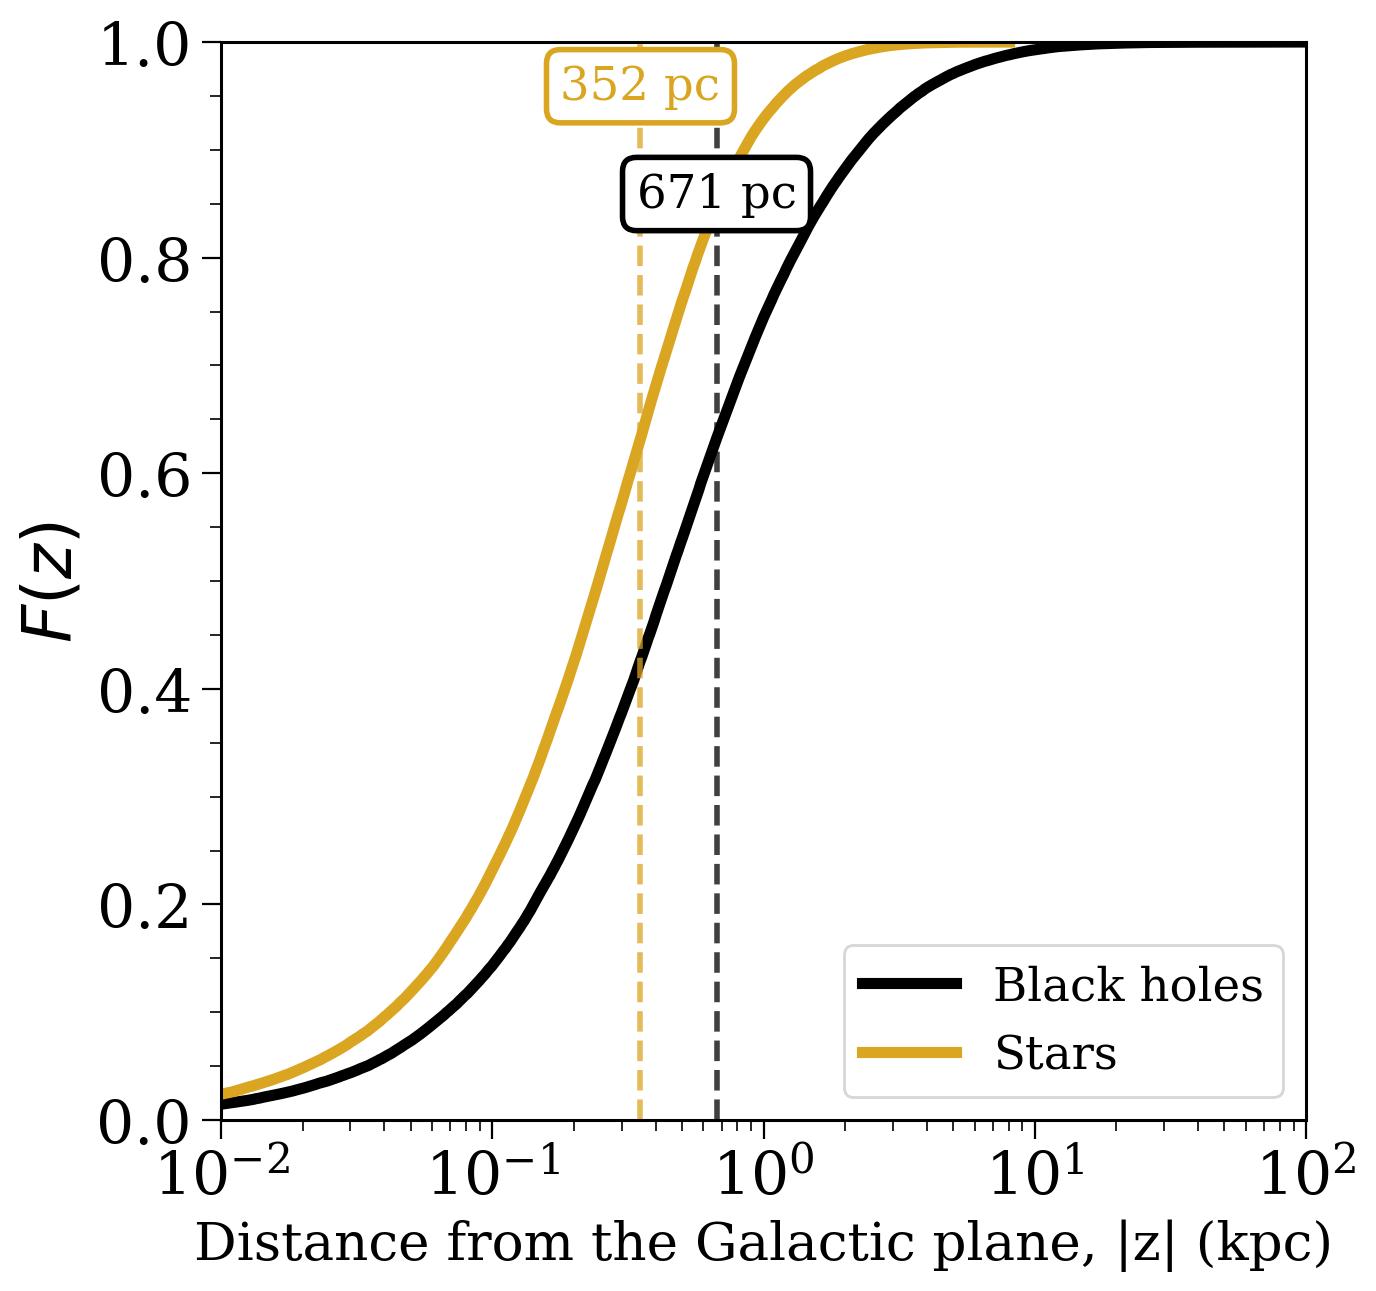

In [15]:
fig, ax = plt.subplots(figsize=(7, 7))

reload(plotting)

for z, R, label, colour, loc in zip(
    [data["Fiducial"]["pos"]["BH"][:, 2][~data["Fiducial"]["escaped"]["BH"]], stars.z],
    [np.sqrt(np.sum(data["Fiducial"]["pos"]["BH"][:, :2]**2, axis=1))[~data["Fiducial"]["escaped"]["BH"]], stars.rho],
    ["Black holes", "Stars", "Neutron stars"],
    ["black", "goldenrod", "tab:purple"],
    [0.98 - 0.1, 0.98, 0.98 - 2 * 0.08]
):

    sh, sh_err, _, _ =plotting.estimate_scale_height_cdf(
        z=z,
        plot=True,
        label=label,
        colour=colour,
        show=False,
        fig=fig,
        ax=ax,
        xlim=(1e-2, 1e2),
        ylim=(0, 1.0),
        # yscale="log",
        scale_height_loc=loc,
        R=R,
    )

# add minor ticks every 0.1 kpc
# ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.05))

# plt.savefig("../plots/scale_height_blackholes_vs_stars.pdf", format="pdf", bbox_inches='tight')
plt.show()

## Compare to Sweeney scale heights

In [16]:
sweeney = pd.read_csv("~/ceph/underworld/sweeney_data/kicked_remnants_igoshev_young_7.8_DC_integrated_final.csv")

73571 objects before Rlims
2283 objects in Rlims


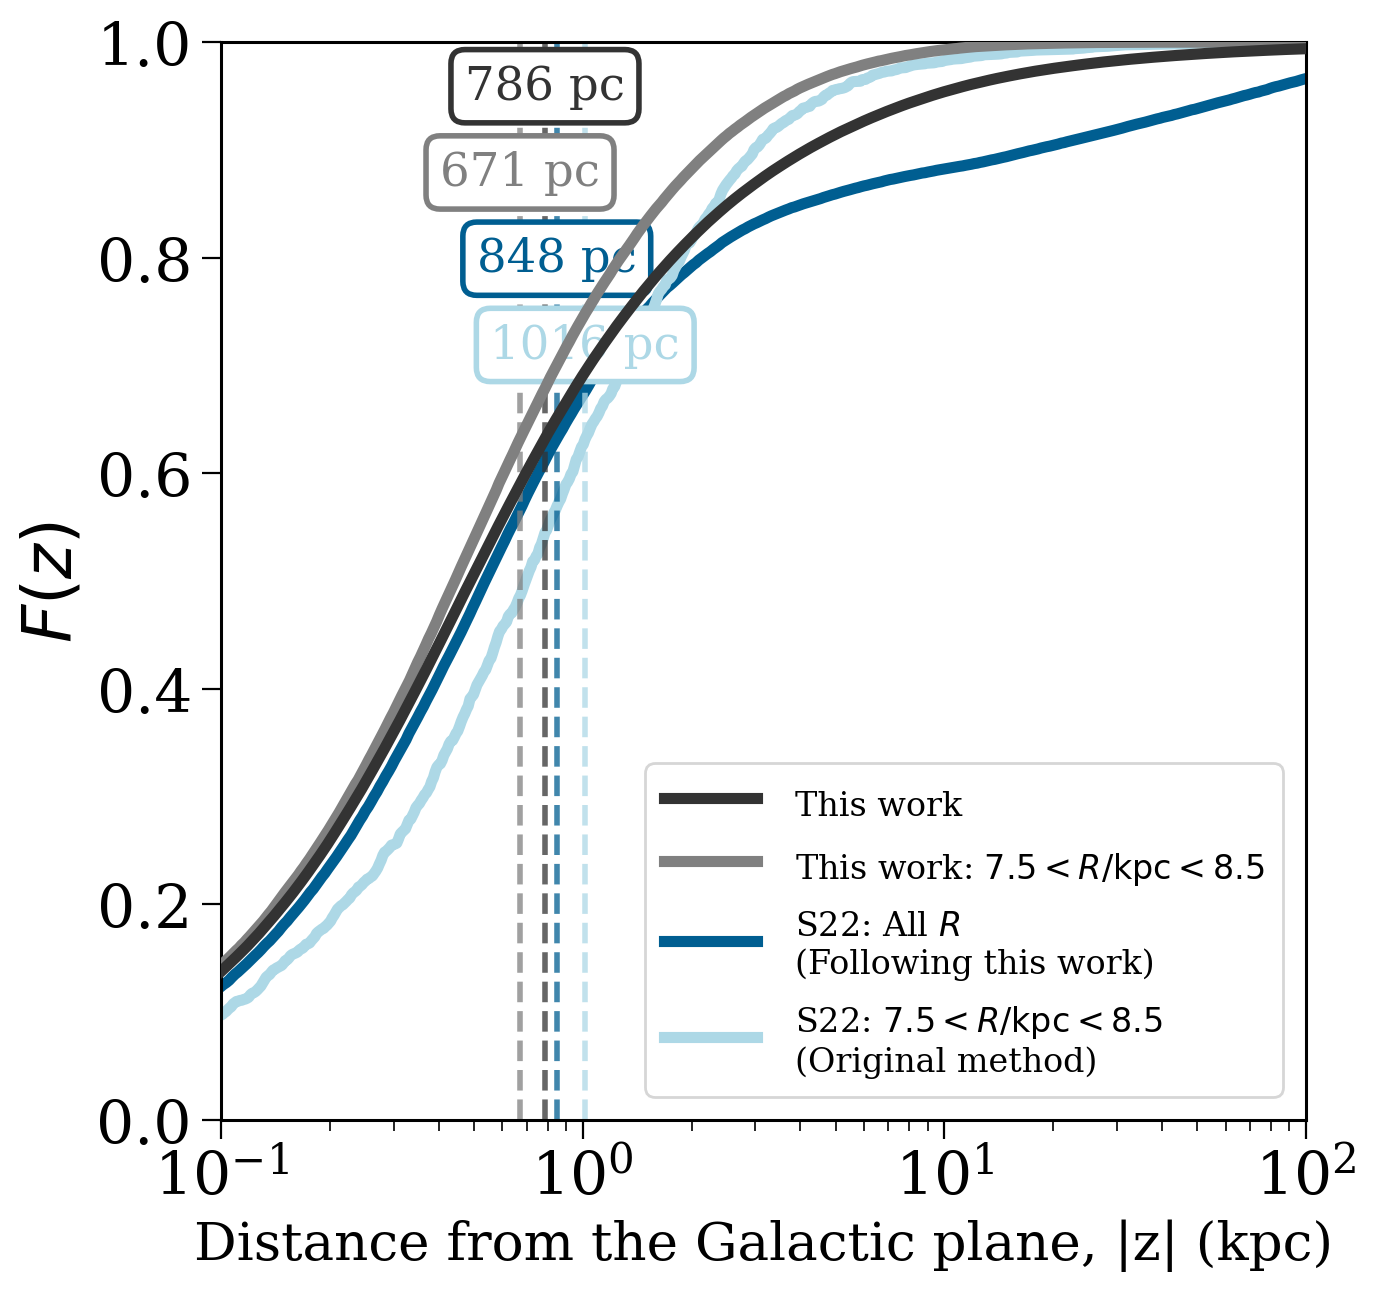

In [17]:
reload(plotting)

sweeney_bhs = sweeney[(sweeney["rtype"] == "Black Hole") & ~sweeney["will_escape"]]

fig, ax = plt.subplots(figsize=(7, 7))

plotting.estimate_scale_height_cdf(
    z=data["Fiducial"]["pos"]["BH"][:, 2][~data["Fiducial"]["escaped"]["BH"]],
    plot=True,
    label=r"This work",
    colour="#333",
    fig=fig,
    ax=ax,
    show=False,
    xlim=(1e-2, 1e2),
    ylim=(0, 1),
    scale_height_loc=0.98,
    zorder=100
)

plotting.estimate_scale_height_cdf(
    z=data["Fiducial"]["pos"]["BH"][:, 2][~data["Fiducial"]["escaped"]["BH"]],
    R=np.linalg.norm(data["Fiducial"]["pos"]["BH"][:, :2], axis=1)[~data["Fiducial"]["escaped"]["BH"]],
    plot=True,
    label=r"This work: $7.5 < R / {\rm kpc} < 8.5$",
    colour="grey",
    fig=fig,
    ax=ax,
    show=False,
    xlim=(1e-2, 1e2),
    ylim=(0, 1),
    scale_height_loc=0.98 - 0.08,
    zorder=99
)

plotting.estimate_scale_height_cdf(
    z=sweeney_bhs["pz"].values * u.kpc,
    plot=True,
    label=r"S22: All $R$" + "\n(Following this work)",
    colour="#005e91",
    fig=fig,
    ax=ax,
    show=False,
    xlim=(1e-2, 1e2),
    ylim=(0, 1),
    scale_height_loc=0.98 - 0.08 * 2,
)

plotting.estimate_scale_height_cdf(
    z=sweeney_bhs["pz"].values * u.kpc,
    R= sweeney_bhs["R"].values * u.kpc,
    plot=True,
    label=r"S22: $7.5 < R / {\rm kpc} < 8.5$" + "\n(Original method)",
    colour="lightblue",
    fig=fig,
    ax=ax,
    show=False,
    xlim=(1e-1, 1e2),
    ylim=(0, 1),
    scale_height_loc=0.98 - 0.08 * 3,
    verbose=True
)

leg = ax.get_legend()
leg.set_loc("lower right")
# leg.set_bbox_to_anchor((1.01, 0.7))
leg.set_title("", prop={'size': 0.6 * fs})
for text in leg.get_texts():
    text.set_fontsize(0.5 * fs)

# ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
# ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))

# plt.savefig("../plots/scale_height_sweeney.pdf", format="pdf", bbox_inches='tight')
plt.show()

In [18]:
WIDTH = 1

R_mids = np.linspace(WIDTH / 2, 15, 50)

R_lims_bounds = [(R - WIDTH / 2, R + WIDTH / 2) for R in R_mids]

scale_height_at_R = np.array([plotting.estimate_scale_height_cdf(
    z=data["Fiducial"]["pos"]["BH"][:, 2][~data["Fiducial"]["escaped"]["BH"]],
    R=np.linalg.norm(data["Fiducial"]["pos"]["BH"][:, :2], axis=1)[~data["Fiducial"]["escaped"]["BH"]],
    plot=False,
    Rlims=R_lims
)[0] for R_lims in R_lims_bounds])

stars_scale_height_at_R = np.array([plotting.estimate_scale_height_cdf(
    z=stars.z,
    R=stars.rho,
    plot=False,
    Rlims=R_lims
)[0] for R_lims in R_lims_bounds])

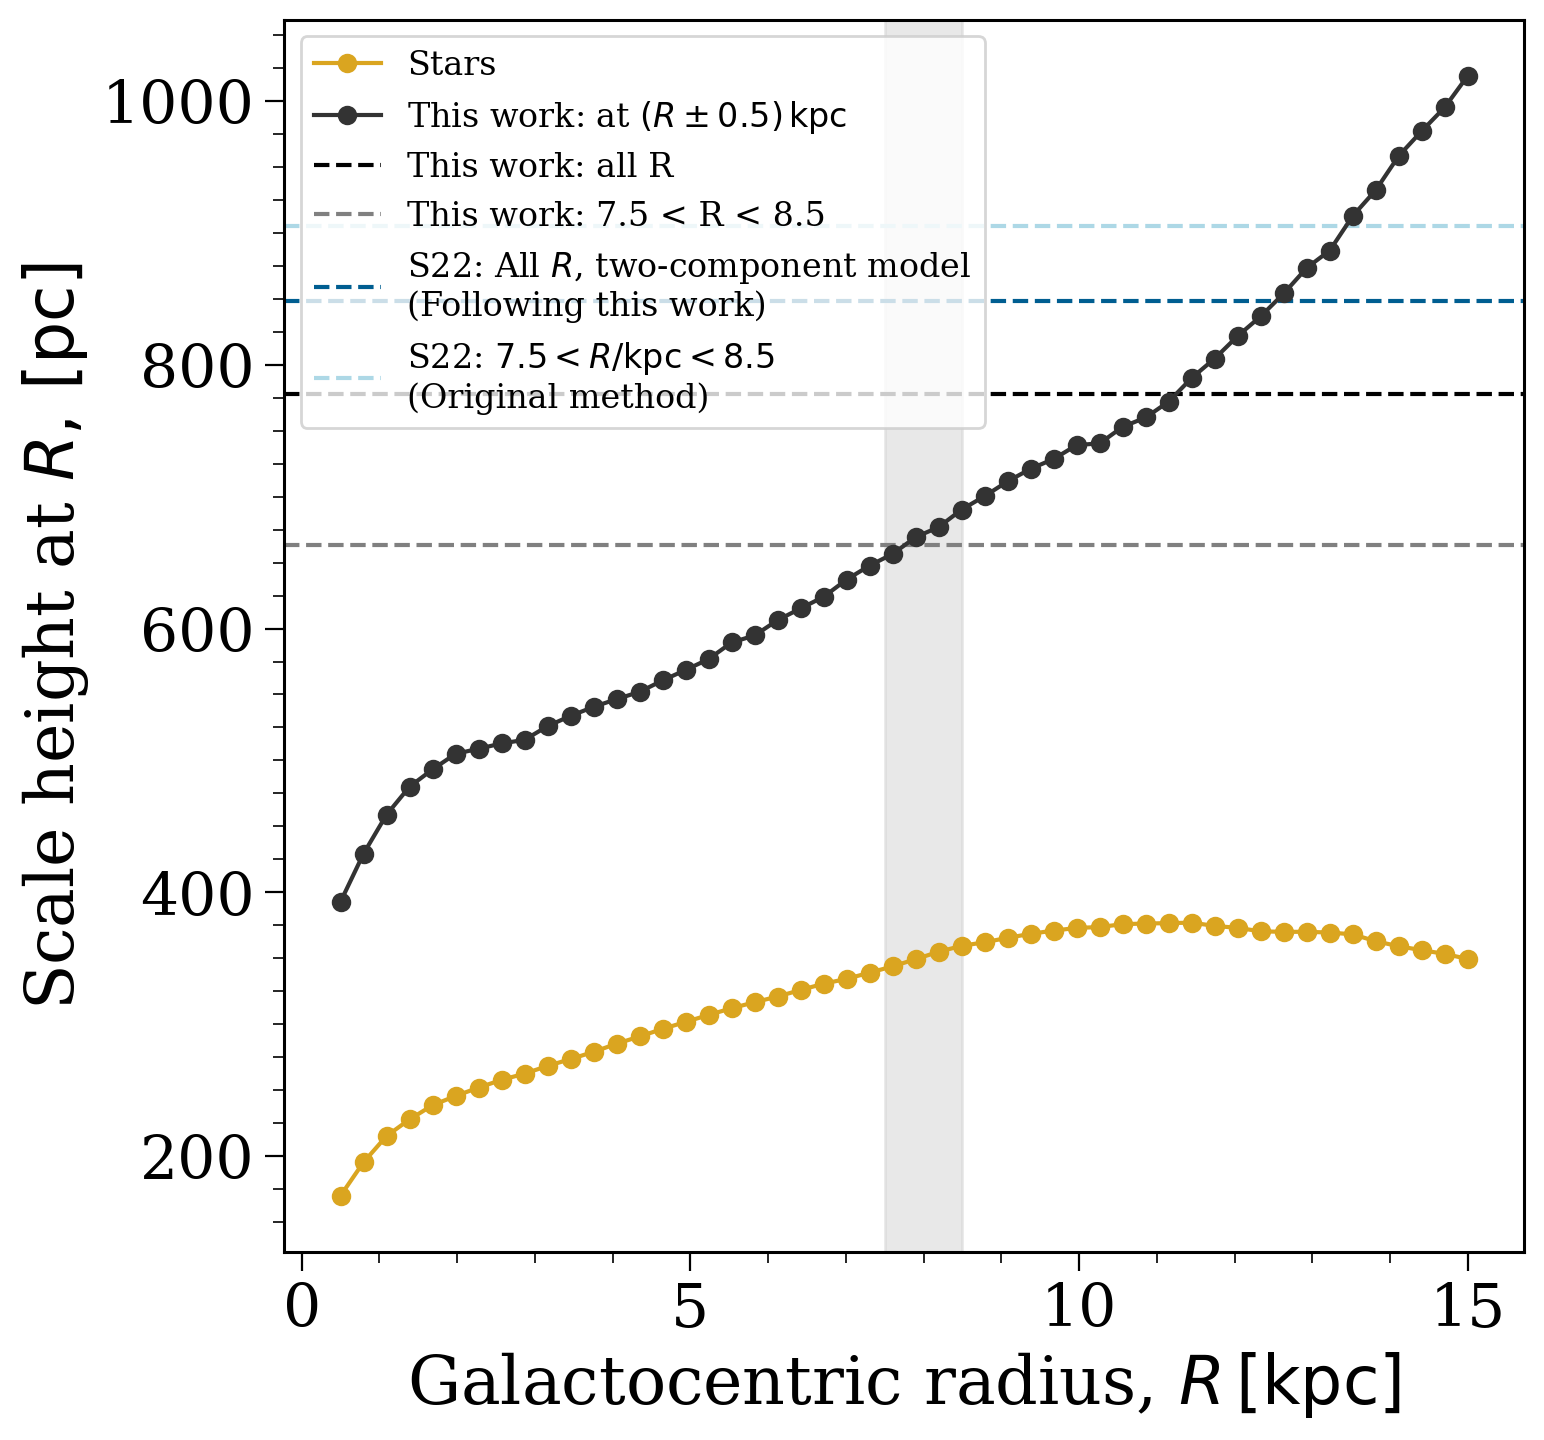

In [20]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(R_mids, stars_scale_height_at_R * 1000, marker="o", color='goldenrod', label=r"Stars")
ax.plot(R_mids, scale_height_at_R * 1000, marker="o", color='#333', label=r"This work: at $(R \pm 0.5) \, {\rm kpc}$")
ax.axhline(778, color='black', linestyle="--", zorder=-1, label="This work: all R")
ax.axhline(663, color='grey', linestyle="--", zorder=-1, label="This work: 7.5 < R < 8.5")
ax.axhline(848, color='#005e91', linestyle="--", zorder=-1, label=r"S22: All $R$, two-component model" + "\n(Following this work)")
ax.axhline(905, color='lightblue', linestyle="--", zorder=-1, label=r"S22: $7.5 < R / {\rm kpc} < 8.5$" + "\n(Original method)")

ax.axvspan(7.5, 8.5, color='lightgrey', alpha=0.5, zorder=-2)

ax.set(
    xlabel=r"Galactocentric radius, $R \, [\rm kpc]$",
    ylabel=r"Scale height at $R, \, [\rm pc]$",
)

ax.legend(ncol=1, fontsize=0.5*fs)

ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(1))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(25))

# plt.savefig("../plots/scale_height_at_R.pdf", format="pdf", bbox_inches='tight')
plt.show()